In [1]:
import pandas as pd
df=pd.read_excel("../data/cleandata.xlsx")
df.head()
#Did I load the dataset correctly?

,date,Power Consumption,Outdoor Temperature,Occupancy
0,2018-05-22 00:00:00,71.98,15.72,1
1,2018-05-22 00:15:00,71.00,15.37,1
2,2018-05-22 00:30:00,65.20,15.27,0
3,2018-05-22 00:45:00,95.90,16.03,0
4,2018-05-22 01:00:00,43.60,15.28,0


In [ ]:
#What information is available in this dataset?
df.info()


NameError: name 'df' is not defined

In [ ]:
#What is the overall behavior of the data
df.describe()


,date,Power Consumption,Outdoor Temperature,Occupancy
count,21262,21262.000000,21262.000000,21262.000000
mean,2018-09-09 19:57:39.636911,71.502539,14.673092,11.741511
min,2018-05-22 00:00:00,4.590000,5.870000,0.000000
25%,2018-07-18 05:03:45,57.090000,11.880000,0.000000
50%,2018-09-17 05:15:00,69.000000,13.830000,2.000000
75%,2018-10-23 21:56:15,83.289471,17.200000,15.000000
max,2018-12-31 23:45:00,180.380000,29.610000,122.000000
std,NaN,21.859203,3.845189,18.693847


In [ ]:
#Is the dataset clean enough for analysis?
df.isnull().sum()

date                   0
Power Consumption      0
Outdoor Temperature    0
Occupancy              0
dtype: int64

In [ ]:
#Is the building occupied most of the time or not
df["Occupancy"].value_counts()

Occupancy
0      7387
1      2358
2      1557
3      1080
4       756
       ... 
122       1
108       1
107       1
101       1
93        1
Name: count, Length: 104, dtype: int64

In [ ]:
#How does power consumption vary with occupancy?
df.groupby("Occupancy")["Power Consumption"].mean()

Occupancy
0      71.972246
1      73.127316
2      75.713708
3      71.984961
4      78.178093
         ...    
110    56.600000
116    56.200000
118    59.100000
119    57.850000
122    54.800000
Name: Power Consumption, Length: 104, dtype: float64

In [23]:
df["date"] = pd.to_datetime(df["date"])

In [25]:
df["hour"] = df["date"].dt.hour

In [ ]:
#At what time of day is energy consumption highest?
hourly_power = df.groupby("hour")["Power Consumption"].mean()

hourly_power

hour
0     79.486374
1     71.802297
2     68.242958
3     64.822755
4     62.171010
5     62.688729
6     60.550273
7     60.091039
8     60.270635
9     60.005732
10    60.548643
11    60.840583
12    60.243475
13    65.803466
14    70.901557
15    75.743234
16    78.868223
17    81.781956
18    84.083768
19    85.569857
20    86.581522
21    87.089294
22    85.350235
23    85.111979
Name: Power Consumption, dtype: float64

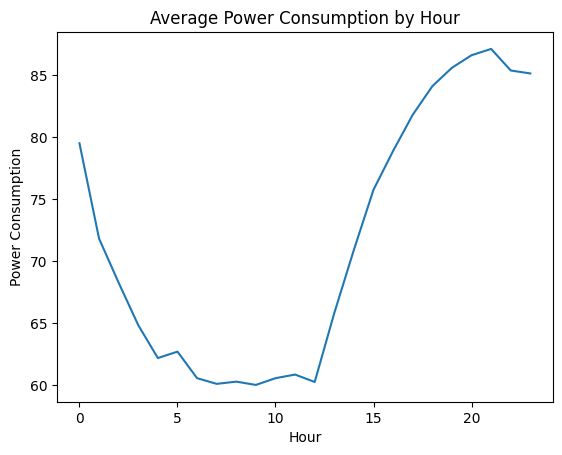

In [29]:
#Can I visually identify patterns?
import matplotlib.pyplot as plt
hourly_power.plot()

plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Power Consumption")

plt.show()


In [4]:
print("Hello, World!")

Hello, World!


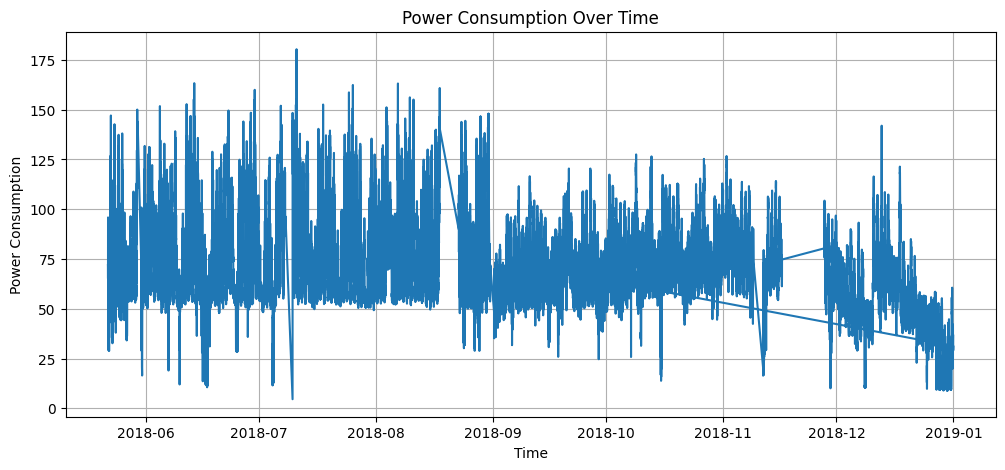

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df["date"],
    df["Power Consumption"]
)

plt.title("Power Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Power Consumption")

plt.grid(True)

plt.show()

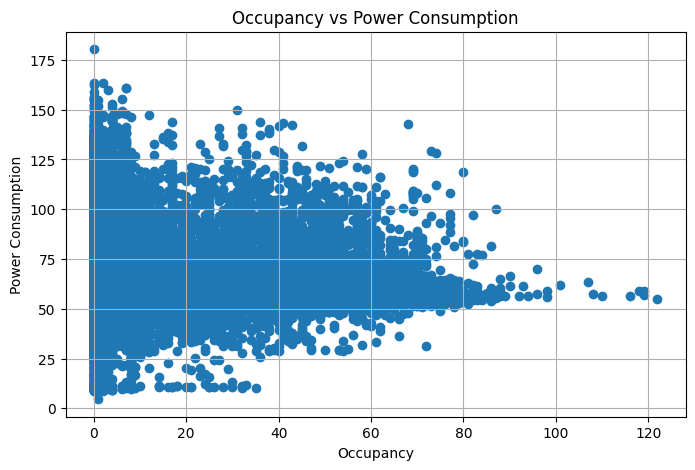

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["Occupancy"],
    df["Power Consumption"]
)

plt.title("Occupancy vs Power Consumption")
plt.xlabel("Occupancy")
plt.ylabel("Power Consumption")

plt.grid(True)

plt.show()

In [11]:
def extract_hour(hour):
    if 0 <= hour <= 3:
        return "Late Night"
    elif 4 <= hour <= 6:
        return "Early Morning"
    elif 7 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 15:
        return "Afternoon"
    elif 16 <= hour <= 19:
        return "Evening"
    else:
        return "Night"

In [13]:
df["date"] = pd.to_datetime(df["date"])

df["Time of Day"] = (
    df["date"]
    .dt.hour
    .apply(extract_hour)
)

In [15]:
print(df["Time of Day"].head())

0    Late Night
1    Late Night
2    Late Night
3    Late Night
4    Late Night
Name: Time of Day, dtype: str


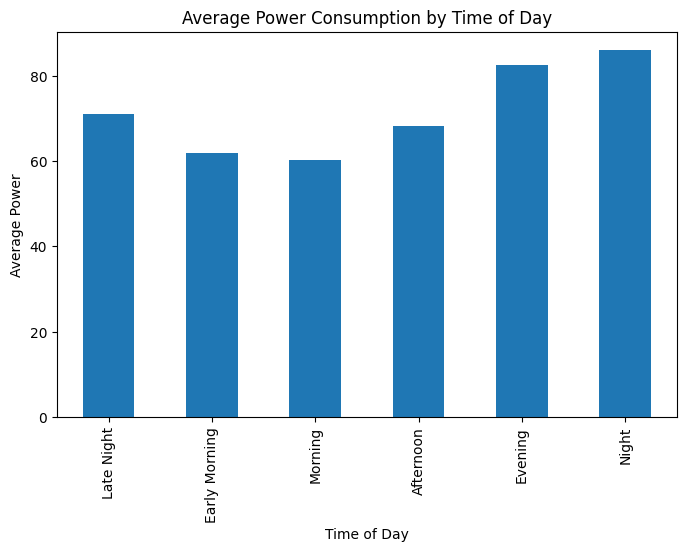

In [17]:
avg_power = (
    df.groupby("Time of Day")
      ["Power Consumption"]
      .mean()
)

avg_power = avg_power.reindex([
    "Late Night",
    "Early Morning",
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
])

avg_power.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Power Consumption by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Power")

plt.show()

In [18]:
waste = df[
    (df["Power Category"] == "High") &
    (df["Occupancy Status"] == "Empty")
]

waste_count = (
    waste["Time of Day"]
    .value_counts()
)

waste_count = waste_count.reindex([
    "Late Night",
    "Early Morning",
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
])

waste_count.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Potential Energy Waste Events")
plt.xlabel("Time of Day")
plt.ylabel("Number of Events")

plt.show()

KeyError: 'Power Category'